# 02 — Calidad extendida sobre las columnas incorporadas

**Proposito.** Auditar la calidad de las columnas que este EDA incorpora por primera vez (proceso y
proveedor), no solo las diez columnas clave que audito el EDA descriptivo previo. Cubre umbrales de
nulidad, valores centinela, outliers de `precio_base`, el residuo de duplicados de la fuente de
adiciones y la caracterizacion completa de los contratos liquidados con estado activo sobre el universo
completo.

**Insumo.** `data/universo_extendido.parquet` (notebook 01) y, para el diagnostico de adiciones,
`entregables/04-datasets/adiciones_obra.parquet` en modo solo lectura.

**Etiquetas de objetivo que atiende:** `[A-OE03]` (normalizacion, calidad y confiabilidad),
`[CALIDAD]` (hallazgos sobre el dato SECOP citables por ambos trabajos), `[B-OE2]` (variables criticas
y su usabilidad real).

**Convencion de trazabilidad.** Las referencias `cNNN` corresponden al `execution_count` de la celda que
produjo la cifra, persistido en el `.ipynb` ejecutado.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
print("Universo extendido:", df.shape)
print("Observables:", int(df["observable"].sum()))

Universo extendido: (48331, 77)
Observables: 19194


## 1. Umbrales de nulidad sobre todas las columnas del universo extendido

Se aplica el mismo criterio de clasificacion del EDA descriptivo previo, ahora sobre las 77 columnas del
dataset extendido y no sobre diez: nulidad <= 20% Apta, <= 50% Uso restringido, > 50% No apta sin
tratamiento adicional. Se separa el reporte por origen (contrato, proceso, proveedor, derivada propia)
porque el diagnostico de cada bloque es distinto.

In [3]:
marcar("umbrales")

ORIGEN = {}
for c in df.columns:
    if c.startswith("pr_") or c in ("precio_base", "valor_adjudicado_proceso", "n_oferentes",
                                    "n_respuestas", "n_invitados", "n_visualizaciones",
                                    "competencia_cat", "plazo_proceso_dias"):
        ORIGEN[c] = "proceso"
    elif c.startswith("prov_") or c == "antiguedad_proveedor_anios":
        ORIGEN[c] = "proveedor"
    elif c in ("plazo_pactado_dias", "plazo_contractual_final_dias", "deslizamiento_plazo_dias",
               "desviacion_costo_pct", "indice_alcance", "rango_cuantia", "plazo_discretizado",
               "tipo_contratista", "observable", "anio_firma", "mes_firma"):
        ORIGEN[c] = "derivada propia"
    else:
        ORIGEN[c] = "contrato"

def clasificar(p):
    return "Apta" if p <= 20 else ("Uso restringido" if p <= 50 else "No apta sin tratamiento")

umbrales = pd.DataFrame({
    "columna": df.columns,
    "origen": [ORIGEN[c] for c in df.columns],
    "nulidad_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "valores_distintos": [int(df[c].nunique(dropna=True)) for c in df.columns],
})
umbrales["clasificacion"] = umbrales["nulidad_pct"].apply(clasificar)
umbrales = umbrales.sort_values(["origen", "nulidad_pct"], ascending=[True, False]).reset_index(drop=True)
umbrales.to_csv(DIR_DATA / "calidad_umbrales_extendido.csv", index=False)

resumen_origen = (umbrales.groupby(["origen", "clasificacion"]).size()
                  .unstack(fill_value=0).reindex(columns=["Apta", "Uso restringido",
                                                          "No apta sin tratamiento"], fill_value=0))
resumen_origen["total"] = resumen_origen.sum(axis=1)
print("Columnas por origen y clasificacion de nulidad:")
print(resumen_origen.to_string())
print()
print("Columnas No apta sin tratamiento:")
print(umbrales[umbrales["clasificacion"] == "No apta sin tratamiento"][
    ["columna", "origen", "nulidad_pct"]].to_string(index=False))

Columnas por origen y clasificacion de nulidad:
clasificacion    Apta  Uso restringido  No apta sin tratamiento  total
origen                                                                
contrato           41                2                        0     43
derivada propia     9                1                        1     11
proceso            15                0                        0     15
proveedor           0                8                        0      8

Columnas No apta sin tratamiento:
             columna          origen  nulidad_pct
desviacion_costo_pct derivada propia      68.8900


## 2. Valores centinela: nulidad aparente frente a nulidad efectiva

SECOP usa valores centinela en lugar de nulos. Una columna con 0% de nulidad puede estar vacia en la
practica. Se evaluan dos familias: centinelas textuales (`No definido`, `No Definido`, `No aplica`,
cadena vacia) y ceros estructurales en variables donde el cero no es un valor legitimo.

In [4]:
marcar("centinelas")

CENTINELAS_TXT = ["No definido", "No Definido", "NO DEFINIDO", "No aplica", "No Aplica",
                  "NO APLICA", "", " ", "N/A", "n/a", "Sin dato", "SIN DATO", "None", "null"]

filas = []
for c in df.columns:
    if df[c].dtype == object:
        s = df[c].astype(str).str.strip()
        n_cent = int(s.isin(CENTINELAS_TXT).sum())
        if n_cent > 0:
            filas.append({"columna": c, "origen": ORIGEN[c], "tipo": "centinela textual",
                          "n": n_cent, "pct": round(n_cent / len(df) * 100, 2),
                          "nulidad_declarada_pct": round(df[c].isna().mean() * 100, 2)})

NUM_CERO_SOSPECHOSO = ["valor_pagado", "valor_facturado", "precio_base", "valor_adjudicado_proceso",
                       "n_oferentes", "n_invitados", "n_visualizaciones", "plazo_proceso_dias"]
for c in NUM_CERO_SOSPECHOSO:
    n0 = int((df[c] == 0).sum())
    filas.append({"columna": c, "origen": ORIGEN[c], "tipo": "cero estructural",
                  "n": n0, "pct": round(n0 / len(df) * 100, 2),
                  "nulidad_declarada_pct": round(df[c].isna().mean() * 100, 2)})

centinelas = pd.DataFrame(filas).sort_values("pct", ascending=False).reset_index(drop=True)
centinelas["nulidad_efectiva_pct"] = (centinelas["pct"] + centinelas["nulidad_declarada_pct"]).round(2)
centinelas.to_csv(DIR_DATA / "calidad_centinelas.csv", index=False)
centinelas.head(20)

,columna,origen,tipo,n,pct,nulidad_declarada_pct,nulidad_efectiva_pct
0,prov_codigo_categoria_principal,proveedor,centinela textual,46958,97.1600,33.5300,130.6900
1,n_invitados,proceso,cero estructural,33833,70.0000,0.0800,70.0800
2,valor_pagado,contrato,cero estructural,33296,68.8900,0.0000,68.8900
3,valor_facturado,contrato,cero estructural,29677,61.4000,0.0000,61.4000
4,prov_codigo,proveedor,centinela textual,16205,33.5300,33.5300,67.0600
5,prov_tipo_empresa,proveedor,centinela textual,16205,33.5300,33.5300,67.0600
6,prov_municipio,proveedor,centinela textual,16205,33.5300,33.5300,67.0600
7,prov_departamento,proveedor,centinela textual,16205,33.5300,33.5300,67.0600
8,prov_espyme,proveedor,centinela textual,16205,33.5300,33.5300,67.0600
9,n_oferentes,proceso,cero estructural,14330,29.6500,0.0800,29.7300


## 3. Outliers y depuracion de `precio_base`

El documento comparativo advierte que `precio_base` contiene valores absurdos (minimo negativo y maximo
del orden de 1e16). Antes de usarlo como valor inicial alternativo (notebook 05) se declara y aplica una
regla de depuracion explicita.

**Regla declarada:** se considera `precio_base` utilizable si `precio_base > 0` y
`precio_base <= 1e13` (diez billones de pesos, cota superior generosa: el contrato de mayor valor del
universo esta un orden de magnitud por debajo). Los valores fuera de ese rango se marcan como no
utilizables, no se imputan y no se eliminan filas: la marca se propaga como `precio_base_valido`.

In [5]:
marcar("precio_base")

pb = df["precio_base"]
diag_pb = pd.DataFrame({
    "criterio": ["No nulo", "Negativo", "Exactamente cero", "Positivo <= 1e13 (valido)",
                 "Positivo > 1e13 (absurdo)"],
    "n": [int(pb.notna().sum()), int((pb < 0).sum()), int((pb == 0).sum()),
          int(((pb > 0) & (pb <= 1e13)).sum()), int((pb > 1e13).sum())],
})
diag_pb["pct_universo"] = (diag_pb["n"] / len(df) * 100).round(2)
print(diag_pb.to_string(index=False))
print()
print("Estadisticos de precio_base SIN depurar:")
print(pb.describe([.01, .25, .5, .75, .99]).to_string())
print()
df["precio_base_valido"] = (pb > 0) & (pb <= 1e13)
print("Estadisticos de precio_base DEPURADO (precio_base_valido):")
print(pb[df["precio_base_valido"]].describe([.01, .25, .5, .75, .99]).to_string())
print()
print(f"Valor maximo descartado: {pb.max():,.0f}")
print(f"Valor minimo descartado: {pb.min():,.0f}")
print(f"Contratos con precio_base utilizable: {int(df['precio_base_valido'].sum()):,} "
      f"({df['precio_base_valido'].mean()*100:.2f}% del universo)")

                 criterio     n  pct_universo
                  No nulo 48293       99.9200
                 Negativo     3        0.0100
         Exactamente cero   585        1.2100
Positivo <= 1e13 (valido) 47704       98.7000
Positivo > 1e13 (absurdo)     1        0.0000

Estadisticos de precio_base SIN depurar:
count               48,293.0000
mean         5,210,136,572.2118
std         82,651,762,119.6348
min           -397,166,484.0000
1%                       0.0000
25%             58,317,642.0000
50%            200,000,000.0000
75%            895,364,000.0000
99%         61,850,409,687.9203
max     13,212,285,859,000.0000

Estadisticos de precio_base DEPURADO (precio_base_valido):
count              47,704.0000
mean        4,997,517,107.4317
std        57,085,586,909.3351
min                     1.0000
1%              5,747,500.0000
25%            60,319,656.5000
50%           205,000,000.0000
75%           907,036,854.0000
99%        62,621,111,139.8001
max     2,354,949,759,5

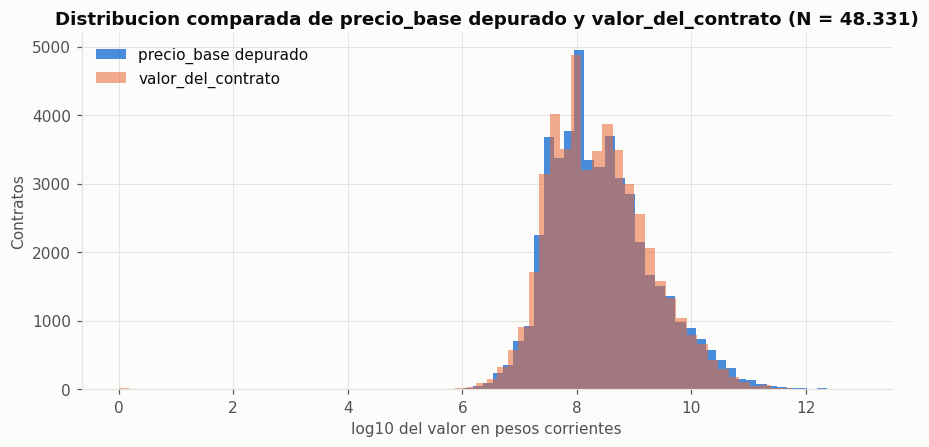

Figura persistida: 02_precio_base_vs_valor.png


In [6]:
marcar("fig_precio_base")

serie = np.log10(pb[df["precio_base_valido"]])
serie_val = np.log10(df.loc[df["valor_del_contrato"] > 0, "valor_del_contrato"])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(serie, bins=70, color=PALETA[0], alpha=0.85, label="precio_base depurado")
ax.hist(serie_val, bins=70, color=PALETA[1], alpha=0.55, label="valor_del_contrato")
ax.set_xlabel("log10 del valor en pesos corrientes")
ax.set_ylabel("Contratos")
ax.set_title("Distribucion comparada de precio_base depurado y valor_del_contrato (N = 48.331)")
ax.legend(loc="upper left")
ax.set_axisbelow(True)
guardar_mostrar(fig, "02_precio_base_vs_valor.png")

## 4. Residuo de duplicados en la fuente de adiciones

La agregacion de modificaciones por contrato (`n_modificaciones_total`, `dias_adicionados`, y las
banderas `tiene_*`) proviene de `adiciones_obra.parquet`. El documento comparativo señala un residuo de
duplicados no resuelto. Se reproduce el diagnostico en fuente porque afecta directamente a variables que
este EDA si utiliza.

In [7]:
marcar("adiciones")

adic = pd.read_parquet(DATASETS / "adiciones_obra.parquet")
n_total = len(adic)
n_filas_identicas = int(adic.duplicated().sum())
n_id_dup = int(adic["identificador"].duplicated().sum())
adic_sin_identicas = adic.drop_duplicates()
n_residuo = int(adic_sin_identicas["identificador"].duplicated().sum())

diag_ad = pd.DataFrame({
    "diagnostico": [
        "Registros de adicion en la fuente",
        "Filas 100% identicas en las 5 columnas",
        "Identificadores repetidos (cualquier contenido)",
        "RESIDUO: identificadores repetidos con contenido distinto tras eliminar filas identicas",
        "Contratos distintos afectados por el residuo",
    ],
    "n": [n_total, n_filas_identicas, n_id_dup, n_residuo,
          int(adic_sin_identicas[adic_sin_identicas["identificador"].duplicated(keep=False)]
              ["id_contrato"].nunique())],
})
diag_ad["pct_fuente"] = (diag_ad["n"] / n_total * 100).round(2)
print(diag_ad.to_string(index=False))
print()
print("El residuo de 8.894 identificadores repetidos con contenido distinto NO se resuelve eliminando")
print("filas identicas. Inflaria los conteos de modificaciones de los contratos afectados.")
print()
ids_res = adic_sin_identicas.loc[
    adic_sin_identicas["identificador"].duplicated(keep=False), "id_contrato"].unique()
afectados = df["id_contrato"].isin(ids_res)
print(f"Contratos del universo afectados por el residuo: {int(afectados.sum()):,} "
      f"({afectados.mean()*100:.2f}%)")
print(f"De ellos, observables: {int((afectados & df['observable']).sum()):,}")
print()
print("Mediana de n_modificaciones_total en contratos afectados vs no afectados:")
print(f"  afectados:    {df.loc[afectados, 'n_modificaciones_total'].median():.1f}")
print(f"  no afectados: {df.loc[~afectados, 'n_modificaciones_total'].median():.1f}")
del adic, adic_sin_identicas

                                                                            diagnostico      n  pct_fuente
                                                      Registros de adicion en la fuente 249037    100.0000
                                                 Filas 100% identicas en las 5 columnas  96942     38.9300
                                        Identificadores repetidos (cualquier contenido) 105836     42.5000
RESIDUO: identificadores repetidos con contenido distinto tras eliminar filas identicas   8894      3.5700
                                           Contratos distintos afectados por el residuo   4782      1.9200

El residuo de 8.894 identificadores repetidos con contenido distinto NO se resuelve eliminando
filas identicas. Inflaria los conteos de modificaciones de los contratos afectados.

Contratos del universo afectados por el residuo: 4,782 (9.89%)
De ellos, observables: 2,163

Mediana de n_modificaciones_total en contratos afectados vs no afectados:
  afectado

## 5. Contratos liquidados con estado activo, sobre el universo completo

El insight N-K03 del EDA descriptivo previo cuantifico 3.538 contratos con `liquidaci_n = 'Si'` y estado
aun activo. Esa cifra corresponde al subconjunto que ya habia superado los cuatro primeros criterios del
embudo. Sobre el universo completo, sin filtrar, la contradiccion es mayor.

In [8]:
marcar("liq_activos")

liq_act = (df["liquidaci_n"] == "Si") & (df["estado_contrato"].isin(ESTADOS_ACTIVOS))
df["liquidado_con_estado_activo"] = liq_act

firma = pd.to_datetime(df["fecha_de_firma"], errors="coerce")
paso4 = ((firma >= "2018-01-01") & (firma <= "2024-12-31")
         & df[["valor_del_contrato", "fecha_de_inicio_del_contrato",
               "fecha_de_fin_del_contrato", "estado_contrato"]].notna().all(axis=1)
         & (df["valor_del_contrato"] > 0)
         & (df["fecha_de_fin_del_contrato"] >= df["fecha_de_inicio_del_contrato"]))

print(f"Sobre el UNIVERSO COMPLETO (N = {len(df):,}): {int(liq_act.sum()):,} contratos "
      f"({liq_act.mean()*100:.2f}%)")
print(f"Sobre el subconjunto que supera los 4 primeros criterios (N = {int(paso4.sum()):,}): "
      f"{int((liq_act & paso4).sum()):,} contratos")
print()
print("La cifra de 3.538 del EDA previo corresponde a la segunda lectura. Sobre el universo completo")
print("la inconsistencia afecta a mas del doble de contratos.")
print()
print("Distribucion por estado_contrato registrado:")
print(df.loc[liq_act, "estado_contrato"].value_counts().to_string())

Sobre el UNIVERSO COMPLETO (N = 48,331): 7,382 contratos (15.27%)
Sobre el subconjunto que supera los 4 primeros criterios (N = 31,543): 3,538 contratos

La cifra de 3.538 del EDA previo corresponde a la segunda lectura. Sobre el universo completo
la inconsistencia afecta a mas del doble de contratos.

Distribucion por estado_contrato registrado:
estado_contrato
En ejecución         4955
Aprobado             1191
Suspendido            651
enviado Proveedor     174
Borrador              170
Cancelado             154
En aprobación          87


In [9]:
marcar("liq_perfil")

def perfil(col, top=8):
    t = df.loc[liq_act, col].value_counts().head(top).to_frame("contratos_liq_activos")
    base_col = df[col].value_counts()
    t["total_universo"] = base_col.reindex(t.index).values
    t["tasa_pct"] = (t["contratos_liq_activos"] / t["total_universo"] * 100).round(2)
    return t

print("=== Por modalidad de contratacion ===")
print(perfil("modalidad_de_contratacion").to_string())
print()
print("=== Por anio de firma ===")
print(perfil("anio_firma", 12).sort_index().to_string())
print()
print("=== Por departamento (top 8) ===")
print(perfil("departamento").to_string())
print()
print("=== Entidades que mas los reportan (top 10) ===")
ent = df.loc[liq_act, "nombre_entidad"].value_counts().head(10).to_frame("contratos_liq_activos")
ent["total_entidad"] = df["nombre_entidad"].value_counts().reindex(ent.index).values
ent["tasa_pct"] = (ent["contratos_liq_activos"] / ent["total_entidad"] * 100).round(1)
print(ent.to_string())
print()
print("Concentracion: las 10 entidades listadas acumulan "
      f"{ent['contratos_liq_activos'].sum() / int(liq_act.sum()) * 100:.1f}% de los casos.")
print()
print("Mediana de valor_del_contrato — liquidados-activos vs resto del universo:")
print(f"  liquidados-activos: {df.loc[liq_act, 'valor_del_contrato'].median():,.0f}")
print(f"  resto:              {df.loc[~liq_act, 'valor_del_contrato'].median():,.0f}")

=== Por modalidad de contratacion ===
                                             contratos_liq_activos  total_universo  tasa_pct
modalidad_de_contratacion                                                                   
Contratación directa                                          2480            9981   24.8500
Selección Abreviada de Menor Cuantía                          1509           12932   11.6700
Mínima cuantía                                                1321            9747   13.5500
Licitación pública Obra Publica                               1074            8575   12.5200
Contratación régimen especial                                  399            2905   13.7300
Contratación régimen especial (con ofertas)                    328            1932   16.9800
Contratación Directa (con ofertas)                             173            1541   11.2300
Licitación pública                                              58             421   13.7800

=== Por anio de firma ===
     

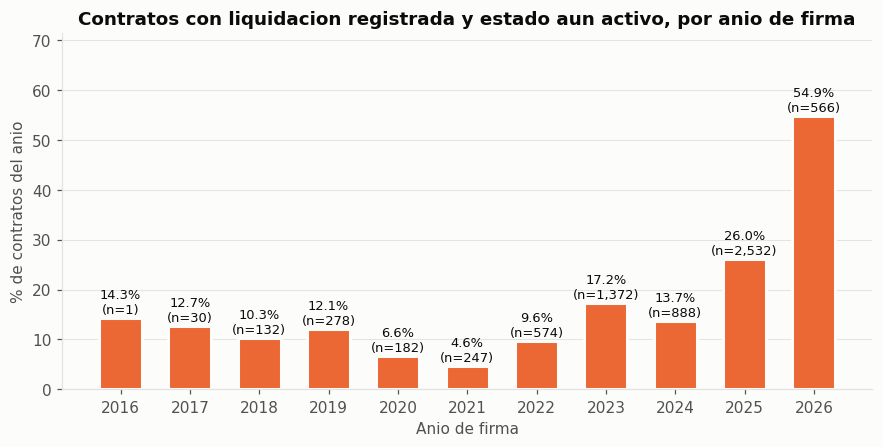

Figura persistida: 02_liquidados_estado_activo_por_anio.png


In [10]:
marcar("fig_liq")

anual = (df.assign(liq=liq_act).groupby("anio_firma")
         .agg(total=("id_contrato", "size"), liq_activos=("liq", "sum")))
anual = anual[anual.index.notna()]
anual["tasa_pct"] = anual["liq_activos"] / anual["total"] * 100

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(anual.index.astype(int).astype(str), anual["tasa_pct"], color=PALETA[1],
       width=0.62, edgecolor=SURFACE, linewidth=2)
for x, v, n in zip(range(len(anual)), anual["tasa_pct"], anual["liq_activos"]):
    ax.text(x, v + 0.35, f"{v:.1f}%\n(n={int(n):,})", ha="center", va="bottom",
            fontsize=8.5, color=TEXT_1)
ax.set_ylim(0, anual["tasa_pct"].max() * 1.30)
ax.set_ylabel("% de contratos del anio")
ax.set_xlabel("Anio de firma")
ax.set_title("Contratos con liquidacion registrada y estado aun activo, por anio de firma")
ax.set_axisbelow(True); ax.xaxis.grid(False)
guardar_mostrar(fig, "02_liquidados_estado_activo_por_anio.png")

## 6. Coherencia de fechas y otros chequeos estructurales

In [11]:
marcar("coherencia")

chk = pd.DataFrame([
    {"chequeo": "fecha_de_fin < fecha_de_inicio",
     "n": int((df["fecha_de_fin_del_contrato"] < df["fecha_de_inicio_del_contrato"]).sum())},
    {"chequeo": "fecha_de_inicio < fecha_de_firma",
     "n": int((df["fecha_de_inicio_del_contrato"] < pd.to_datetime(df["fecha_de_firma"], errors="coerce")).sum())},
    {"chequeo": "valor_del_contrato <= 0",
     "n": int((df["valor_del_contrato"] <= 0).sum())},
    {"chequeo": "valor_pagado > valor_del_contrato",
     "n": int((df["valor_pagado"] > df["valor_del_contrato"]).sum())},
    {"chequeo": "valor_pagado == 0",
     "n": int((df["valor_pagado"] == 0).sum())},
    {"chequeo": "plazo_contractual_final_dias negativo",
     "n": int((df["plazo_contractual_final_dias"] < 0).sum())},
    {"chequeo": "plazo_pactado_dias no parseable",
     "n": int(df["plazo_pactado_dias"].isna().sum())},
    {"chequeo": "fecha_de_firma fuera de 2018-2024 o nula",
     "n": int((~((pd.to_datetime(df['fecha_de_firma'], errors='coerce') >= '2018-01-01')
                 & (pd.to_datetime(df['fecha_de_firma'], errors='coerce') <= '2024-12-31'))).sum())},
])
chk["pct_universo"] = (chk["n"] / len(df) * 100).round(2)
chk

,chequeo,n,pct_universo
0,fecha_de_fin < fecha_de_inicio,23,0.0500
1,fecha_de_inicio < fecha_de_firma,2706,5.6000
2,valor_del_contrato <= 0,696,1.4400
3,valor_pagado > valor_del_contrato,20,0.0400
4,valor_pagado == 0,33296,68.8900
5,plazo_contractual_final_dias negativo,23,0.0500
6,plazo_pactado_dias no parseable,6212,12.8500
7,fecha_de_firma fuera de 2018-2024 o nula,16156,33.4300


## 7. Persistencia y sintesis de hallazgos etiquetados

In [12]:
df[["id_contrato", "precio_base_valido", "liquidado_con_estado_activo"]].to_parquet(
    DIR_DATA / "marcas_calidad.parquet", index=False)

reg = RegistroHallazgos("02")
reg.add("H02-01",
        "Sobre el universo completo hay 7.382 contratos con liquidacion registrada y estado aun activo, mas del doble de los 3.538 reportados por el EDA previo",
        f"{int(liq_act.sum()):,} sobre 48.331 ({liq_act.mean()*100:.2f}%); {int((liq_act & paso4).sum()):,} sobre el subconjunto filtrado",
        ref("liq_activos"), ["CALIDAD", "A-OE03", "B-OE2"], "Alto",
        "La cifra previa se calculo despues de cuatro filtros; la cifra sobre el universo es la correcta para caracterizar la fuente")
reg.add("H02-02",
        "La inconsistencia liquidado-activo no esta distribuida al azar: se concentra en pocas entidades y crece en los anios recientes",
        f"Las 10 entidades con mas casos acumulan {ent['contratos_liq_activos'].sum()/int(liq_act.sum())*100:.1f}% del total",
        ref("liq_perfil"), ["CALIDAD", "B-OE2"], "Alto",
        "Sugiere practica de reporte de entidad, no error aleatorio de captura")
reg.add("H02-03",
        "`precio_base` requiere depuracion previa: contiene valores negativos y magnitudes absurdas",
        f"minimo {pb.min():,.0f}; maximo {pb.max():,.0f}; utilizables {int(df['precio_base_valido'].sum()):,} ({df['precio_base_valido'].mean()*100:.2f}%)",
        ref("precio_base"), ["CALIDAD", "A-OE03"], "Alto",
        "Regla declarada: 0 < precio_base <= 1e13; no se imputa ni se eliminan filas, se marca")
reg.add("H02-04",
        "La fuente de adiciones arrastra 8.894 identificadores repetidos con contenido distinto que la eliminacion de filas identicas no resuelve",
        f"{n_total:,} registros; {n_filas_identicas:,} filas identicas; residuo {n_residuo:,}",
        ref("adiciones"), ["CALIDAD"], "Alto",
        "Afecta a las agregaciones de modificaciones por contrato que este EDA si utiliza")
reg.add("H02-05",
        "El 68.9% del universo registra valor_pagado en cero; el filtro de observabilidad lo reduce a 54.8% pero no lo resuelve",
        f"{int((df['valor_pagado']==0).sum()):,} de 48.331 en el universo", ref("coherencia"),
        ["CALIDAD", "A-OE03", "B-OE2"], "Alto",
        "Extension de N-K04 al universo completo")
reg.add("H02-06",
        "Ninguna columna de proceso incorporada supera el umbral de nulidad: la cobertura del join es del 99.92% y las variables llegan completas",
        "Clasificacion de nulidad por origen en la tabla de umbrales", ref("umbrales"),
        ["A-OE03", "B-OE2"], "Medio",
        "El bloque de proveedor si tiene nulidad estructural del 33.5% por cobertura del registro")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H02-01,02,c009,Sobre el universo completo hay 7.382 contratos...,"7,382 sobre 48.331 (15.27%); 3,538 sobre el su...",[CALIDAD] [A-OE03] [B-OE2],Alto,La cifra previa se calculo despues de cuatro f...
1,H02-02,02,c010,La inconsistencia liquidado-activo no esta dis...,Las 10 entidades con mas casos acumulan 32.2% ...,[CALIDAD] [B-OE2],Alto,"Sugiere practica de reporte de entidad, no err..."
2,H02-03,02,c006,`precio_base` requiere depuracion previa: cont...,"minimo -397,166,484; maximo 13,212,285,859,000...",[CALIDAD] [A-OE03],Alto,Regla declarada: 0 < precio_base <= 1e13; no s...
3,H02-04,02,c008,La fuente de adiciones arrastra 8.894 identifi...,"249,037 registros; 96,942 filas identicas; res...",[CALIDAD],Alto,Afecta a las agregaciones de modificaciones po...
4,H02-05,02,c012,El 68.9% del universo registra valor_pagado en...,"33,296 de 48.331 en el universo",[CALIDAD] [A-OE03] [B-OE2],Alto,Extension de N-K04 al universo completo
5,H02-06,02,c004,Ninguna columna de proceso incorporada supera ...,Clasificacion de nulidad por origen en la tabl...,[A-OE03] [B-OE2],Medio,El bloque de proveedor si tiene nulidad estruc...


## Sintesis del notebook 02

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H02-01 | Sobre el universo completo hay 7.382 contratos liquidados con estado activo, no 3.538 | `[CALIDAD]` `[A-OE03]` `[B-OE2]` |
| H02-02 | La inconsistencia se concentra en pocas entidades: practica de reporte, no error aleatorio | `[CALIDAD]` `[B-OE2]` |
| H02-03 | `precio_base` exige depuracion declarada antes de usarse como valor inicial alternativo | `[CALIDAD]` `[A-OE03]` |
| H02-04 | Residuo de 8.894 identificadores duplicados en adiciones, no resuelto por el pipeline | `[CALIDAD]` |
| H02-05 | 68,9% de pagos en cero sobre el universo; 54,8% tras el filtro de observabilidad | `[CALIDAD]` `[A-OE03]` `[B-OE2]` |
| H02-06 | Las columnas de proceso llegan completas; el bloque de proveedor tiene nulidad estructural | `[A-OE03]` `[B-OE2]` |

**Productos persistidos:** `data/calidad_umbrales_extendido.csv`, `data/calidad_centinelas.csv`,
`data/marcas_calidad.parquet`, `figuras/02_precio_base_vs_valor.png`,
`figuras/02_liquidados_estado_activo_por_anio.png`.

**Como responder a un jurado.** La objecion previsible es "¿por que el numero de contratos liquidados con
estado activo cambio respecto del EDA anterior?". La respuesta es que no cambio el dato sino el
denominador: 3.538 es el conteo dentro del subconjunto ya filtrado por fecha, campos minimos, valor y
coherencia de fechas; 7.382 es el conteo sobre el universo completo. Ambas cifras son correctas en su
contexto y aqui se reportan las dos.